<a href="https://colab.research.google.com/github/Feliz-ua/goit-np-hw-11/blob/main/hw-11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.2 MB/s eta 0:00:00


In [37]:
# 1. Завантаження бібліотеки PyGad та підготовка даних про товари
import pygad
import numpy as np
import warnings

names = ['Refrigerator A', 'Cell phone', 'TV 55', "TV 50'", "TV 42'", 'Notebook A', 'Ventilator', 'Microwave A', 'Microwave B', 'Microwave C', 'Refrigerator B', 'Refrigerator C', 'Notebook B', 'Notebook C']
spaces = [0.751, 8.99e-06, 0.4, 0.29, 0.2, 0.0035, 0.496, 0.0424, 0.0544, 0.0319, 0.635, 0.87, 0.498, 0.527]
prices = [999.9, 2199.12, 4346.99, 3999.9, 2999.0, 2499.9, 199.9, 308.66, 429.9, 299.29, 849.0, 1199.89, 1999.9, 3999.0]
space_limit = 3.0


print(f"{'Назва товару':<18} | {'Ціна':<10} | {'Об`єм':<10}")
print("-" * 45)

for name, price, space in zip(names, prices, spaces):
    print(f"{name:<18} | {price:<10} | {space:<10}")

Назва товару       | Ціна       | Об`єм     
---------------------------------------------
Refrigerator A     | 999.9      | 0.751     
Cell phone         | 2199.12    | 8.99e-06  
TV 55              | 4346.99    | 0.4       
TV 50'             | 3999.9     | 0.29      
TV 42'             | 2999.0     | 0.2       
Notebook A         | 2499.9     | 0.0035    
Ventilator         | 199.9      | 0.496     
Microwave A        | 308.66     | 0.0424    
Microwave B        | 429.9      | 0.0544    
Microwave C        | 299.29     | 0.0319    
Refrigerator B     | 849.0      | 0.635     
Refrigerator C     | 1199.89    | 0.87      
Notebook B         | 1999.9     | 0.498     
Notebook C         | 3999.0     | 0.527     


In [42]:
# 2. Визначення фітнес-функції
def fitness_func(ga_instance, solution, solution_idx):
    total_space = np.sum(solution * spaces)
    total_price = np.sum(solution * prices)

    # Перевірка обмеження: якщо сумарний об'єм перевищує ліміт вантажівки,
    # розв'язок отримує найнижчу оцінку (0), оскільки він є недопустимим.
    if total_space > space_limit:
        return 0
    return total_price

In [16]:
# 3. Визначення початкової популяції
# Для нашої задачі кожен ген у хромосомі відповідає товару і може приймати значення 0 (не беремо) або 1 (беремо).
num_genes = len(spaces)
gene_space = [0, 1]

In [17]:
# 4. Задання параметрів генетичного алгоритму
sol_per_pop = 50           # кількість хромосом у популяції
num_generations = 100      # кількість поколінь
num_parents_mating = 25    # кількість батьків для кросоверу

# Тип кросоверу та мутації
crossover_type = "single_point" # Одноточковий кросовер
mutation_type = "random"        # Випадкова мутація
mutation_probability = 0.1      # Ймовірність мутації (10%)

Найкращий знайдений розв'язок (хромосома): [0 1 1 1 1 1 0 0 1 1 0 1 1 1]
Максимальна вартість товарів: 23972.89
Використаний об'єм у вантажівці: 2.8748 / 3.0
Обрані товари: ['Cell phone', 'TV 55', "TV 50'", "TV 42'", 'Notebook A', 'Microwave B', 'Microwave C', 'Refrigerator C', 'Notebook B', 'Notebook C']
Загальна вартість: 23972.89
Загальний об'єм: 2.8748 куб.м. (Ліміт: 3.0)


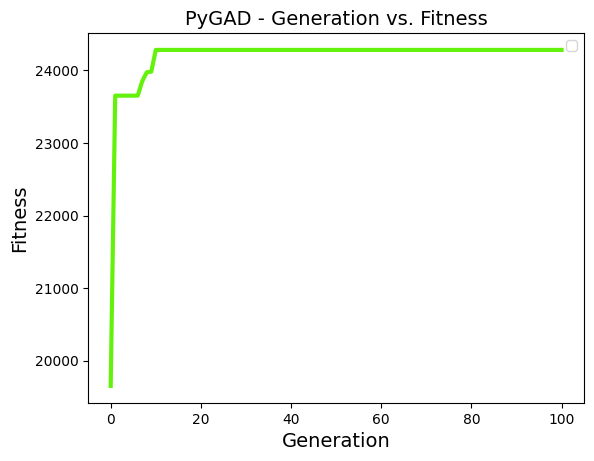

In [22]:
# 5. Створення екземпляра генетичного алгоритму засобами PyGad
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_func,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       gene_type=int,           # Гени повинні бути цілими числами
                       gene_space=gene_space,   # Обмеження генів значеннями 0 та 1
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_probability=mutation_probability)

warnings.filterwarnings(
    "ignore",
    message="No artists with labels found to put in legend."
)
# Запуск еволюційного процесу
ga_instance.run()

# Відображення найкращого знайденого результату
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Найкращий знайдений розв'язок (хромосома): {solution}")
print(f"Максимальна вартість товарів: {solution_fitness}")
print(f"Використаний об'єм у вантажівці: {np.sum(solution * spaces):.4f} / {space_limit}")

# Розшифровуємо, які товари ми взяли
selected_items = [names[i] for i in range(len(solution)) if solution[i] == 1]
print(f"Обрані товари: {selected_items}")
print(f"Загальна вартість: {solution_fitness}")
print(f"Загальний об'єм: {np.sum(solution * spaces):.4f} куб.м. (Ліміт: {space_limit})")

# Відображення графіку збіжності
ga_instance.plot_fitness();
